# Data Loading & Preprocessing

In [1]:
import pandas as pd

import sys
import os

os.chdir("../")

os.getcwd()

# ^^^makes sure current working directory is the correct one

'c:\\Users\\ldiaz\\OneDrive\\Desktop\\CHE 4230\\meter_Hw4'

In [2]:
from src.data_preprocess import DataPreprocessing 

# Using preprocessing parent class which will load the data and preprocess it by dropping N/A's and turning to numpy fuctionality

preprocessor = DataPreprocessing()

data = preprocessor.load_data("data/Meter_A.txt")

         0         1         2         3          4          5         6   \
0  0.841499  1.009367  0.993816  8.469805  10.278727  10.037759  8.501365   
1  0.842250  1.006584  0.996605  7.531891   9.139924   8.951618  7.612213   
2  0.840723  1.011647  0.998152  6.641699   7.975464   7.857692  6.593117   
3  0.841119  1.017807  0.996812  5.687524   6.824334   6.689885  5.615428   
4  0.840358  1.016534  0.996221  5.660385   6.829560   6.675628  5.623977   

         7          8          9   ...         27         28         29  \
0  8.581726  10.247763  10.058822  ...  32.451173  34.568685  33.082683   
1  7.623325   9.106345   8.945142  ...  32.428385  34.441732  33.081055   
2  6.681572   7.964596   7.814698  ...  32.428385  34.275715  33.113605   
3  5.763315   6.801051   6.686639  ...  32.485350  34.080403  33.170573   
4  5.736818   6.813453   6.672377  ...  32.503255  34.122720  33.164062   

          30         31         32         33         34         35  36  
0  36.722005

# Going to add training,testing, and validation data splitting to preprocessing parent class seen in 3.0_Model_built.ipynb

In [3]:
from sklearn.model_selection import train_test_split

train_validation, test = train_test_split(data, test_size = 0.2, random_state=12)

train, validation = train_test_split(train_validation, test_size = 0.2, random_state=99)

# Check data spread in training, validation, and testing

print("Train:", set(train[:, -1]))
print("Validation:", set(validation[:, -1]))
print("Test:", set(test[:, -1]))

# result demonstrates each split contains the same two classes
# this ensures no other labels exist and the analysis will be thorough

X_train = train[:, :-1]
y_train = train[:, -1]

X_val = validation[:, :-1]
y_val = validation[:, -1]

X_test = test[:, :-1]
y_test = test[:, -1]

Train: {np.float64(1.0), np.float64(2.0)}
Validation: {np.float64(1.0), np.float64(2.0)}
Test: {np.float64(1.0), np.float64(2.0)}


# Going to add standardization process seen in 3.0_Model_built.ipynb

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


# Retrieving scikit learn MLPRegressor class

In [29]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

hidden_layer_sizes = (64, 32)
learning_rate_init = 0.001
max_iter = 300

model = MLPRegressor(
    hidden_layer_sizes=hidden_layer_sizes,
    learning_rate_init=learning_rate_init,
    max_iter=max_iter,
    activation='relu',
    solver='adam',
    random_state=42
)
model

# Training model here
model.fit(X_train_scaled, y_train)

# Predicted values
y_pred = model.predict(X_test_scaled)

# Checking accuracy
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(mse, r2)

0.08858551771298075 0.6456579291480771


In [ ]:
# Visualizing
import matplotlib.pyplot

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("MLPRegressor Performance")
plt.grid(True)
plt.show()

# Retrieve MLPClassifier to test it

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


hidden_layer_sizes = (64, 32)
learning_rate_init = 0.001
max_iter = 300

model = MLPClassifier(
    hidden_layer_sizes=hidden_layer_sizes,
    learning_rate_init=learning_rate_init,
    max_iter=max_iter,
    activation='relu',
    solver='adam',
    random_state=42
)
model

# Training model here
model.fit(X_train_scaled, y_train)

# Predicted values
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9444444444444444

Classification Report:
              precision    recall  f1-score   support

         1.0       0.90      1.00      0.95         9
         2.0       1.00      0.89      0.94         9

    accuracy                           0.94        18
   macro avg       0.95      0.94      0.94        18
weighted avg       0.95      0.94      0.94        18


Confusion Matrix:
[[9 0]
 [1 8]]


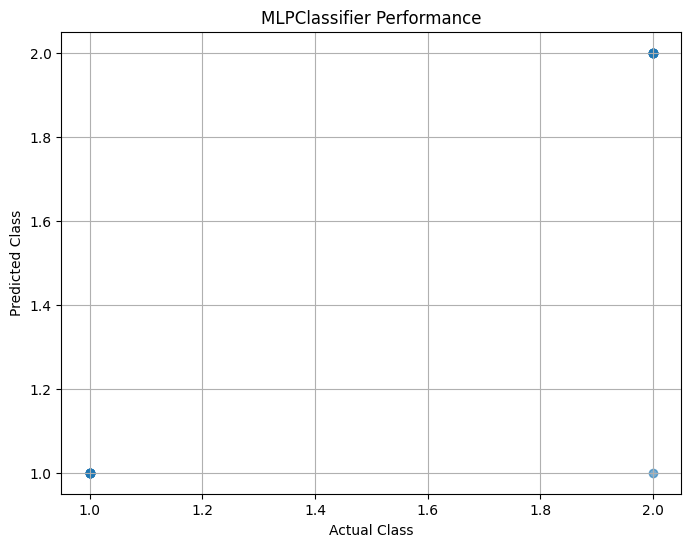

In [31]:
# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Class")
plt.ylabel("Predicted Class")
plt.title("MLPClassifier Performance")
plt.grid(True)
plt.show()